# Relationships between ENSO and RO Parameters in CMIP6

This tutorial demonstrates how to use pyCRO to explore the relationships between ENSO amplitude/skewness and Recharge Oscillator (RO) parameters, for both observations and all CMIP6 models.

Contact:
 - Sen Zhao (zhaos@hawaii.edu)

## Load library

In [35]:
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

import os
import sys
    
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## comment this if you install pyCRO already
sys.path.append(os.path.abspath("../../../"))

import senpy as sp

import pyCRO

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load ENSO timeseries from OBS and CMIP6 models

In [2]:
# load observations
obs_file = os.path.join(os.getcwd(), "../../../data", "CROdata_timeseries_oras5.nc")
obs_ds = xr.open_dataset(obs_file)
obs_ds

<xarray.Dataset> Size: 18kB
Dimensions:  (time: 756)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2020-12-01
Data variables:
    Nino3    (time) float32 3kB ...
    Nino34   (time) float32 3kB ...
    Hm       (time) float32 3kB ...
    Hw       (time) float32 3kB ...

In [4]:
## CMIP6 
cmip_file = os.path.join(os.getcwd(), "../../../data", "CROdata_timeseries_CMIP6.nc")
cmip_ds = xr.open_dataset(cmip_file)
cmip_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (model: 48, time: 1332)
Coordinates:
  * time     (time) datetime64[ns] 11kB 1900-01-01 1900-02-01 ... 2010-12-01
  * model    (model) <U15 3kB 'ACCESS-CM2' 'ACCESS-ESM1-5' ... 'UKESM1-0-LL'
Data variables:
    Nino3    (model, time) float32 256kB ...
    Nino34   (model, time) float32 256kB ...
    Hm       (model, time) float32 256kB ...
    Hw       (model, time) float32 256kB ...

## Fitting RO to the OBS and CMIP6 models

In [15]:
def fit_dict_to_dataset(fit_dict):
    """
    Convert a single fit dictionary into an xarray.Dataset.
    Assigns dimensions based on the length of the parameter list:
        len=1 -> 'ac_0'
        len=3 -> 'ac_1'
        len=5 -> 'ac_2'
    Empty lists are replaced with np.nan (float).

    Parameters
    ----------
    fit_dict : dict
        Dictionary where keys are parameter names and values are lists.

    Returns
    -------
    xr.Dataset
    """
    data_vars = {}

    for k, v in fit_dict.items():
        if len(v) == 0:
            arr = np.array([np.nan], dtype=float)
            dim = "ac_0"
        elif len(v) == 1:
            arr = np.array(v, dtype=float)
            dim = "ac_0"
        elif len(v) == 3:
            arr = np.array(v, dtype=float)
            dim = "ac_1"
        elif len(v) == 5:
            arr = np.array(v, dtype=float)
            dim = "ac_2"
        else:
            # Other lengths: convert to float, pad with nan if needed
            arr = np.array(v, dtype=float)
            dim = f"ac_{len(v)}"

        data_vars[k] = (dim, arr)

    out_ds = xr.Dataset(data_vars)

    if 'R' in out_ds.data_vars and 'epsilon' in out_ds.data_vars:
        out_ds['BJ'] = (out_ds['R'] - out_ds['epsilon'])*0.5
    return out_ds


def CRO_obs_fitting(par_option_T, par_option_h, par_option_noise, verbose=False):
    """
        fit obs with the T, h, and noise options
    """

    par_tmp = pyCRO.RO_fitting(obs_ds['Nino34'], obs_ds['Hm'],
                               par_option_T, par_option_h, par_option_noise, verbose=verbose)
    par_ds = fit_dict_to_dataset(par_tmp).assign_coords({'model': 'ORAS5'})
    return par_ds


def CRO_cmip_fitting(par_option_T, par_option_h, par_option_noise, verbose=False):
    """
        fit all cmip6 models with the same T, h, and noise options
    """

    for i, model in enumerate(cmip_ds.model.values):
        par_tmp = pyCRO.RO_fitting(cmip_ds['Nino34'].sel(model=model), cmip_ds['Hm'].sel(model=model), 
                                   par_option_T, par_option_h, par_option_noise, verbose=verbose)        
        par_ds = fit_dict_to_dataset(par_tmp).assign_coords({'model': model})

        if i==0:
            par_cmip = par_ds
        else:
            par_cmip = xr.concat([par_cmip, par_ds], dim='model')
    return par_cmip


In [4]:
par_option_T = {"R": 1, "F1": 1, "b_T": 0, "c_T": 0, "d_T": 0}
par_option_h = {"F2": 1, "epsilon": 1, "b_h": 0}
par_option_noise = {"T": "white", "h": "white", "T_type": "additive"}

par_cmip_LWA = CRO_cmip6_fitting(par_option_T, par_option_h, par_option_noise)
par_cmip_LWA

<xarray.Dataset> Size: 9kB
Dimensions:  (model: 48, ac_0: 1)
Coordinates:
  * model    (model) <U15 3kB 'ACCESS-CM2' 'ACCESS-ESM1-5' ... 'UKESM1-0-LL'
Dimensions without coordinates: ac_0
Data variables: (12/16)
    R        (model, ac_0) float64 384B -0.0277 0.04347 ... 0.07818 0.006757
    F1       (model, ac_0) float64 384B 0.03008 0.0195 ... 0.03125 0.02193
    F2       (model, ac_0) float64 384B 1.138 1.671 1.259 ... 1.106 1.602 1.103
    epsilon  (model, ac_0) float64 384B 0.08306 0.1292 0.1211 ... 0.1831 0.09856
    b_T      (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    c_T      (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    ...       ...
    B        (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    m_T      (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    m_h      (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    n_T      (model, ac_0) float64 384B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    n_h      (model, ac_0) float64 384B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    n_g      (model, ac_0) float64 384B 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0

### Type: Nonlinear-White-Additive

Fit nonlinear RO with red and additive noise 


In [16]:
par_option_T = {"R": 1, "F1": 1, "b_T": 1, "c_T": 1, "d_T": 1}
par_option_h = {"F2": 1, "epsilon": 1, "b_h": 1}
par_option_noise = {"T": "white", "h": "white", "T_type": "additive"}

par_obs = CRO_obs_fitting(par_option_T, par_option_h, par_option_noise)

par_cmip = CRO_cmip_fitting(par_option_T, par_option_h, par_option_noise)
par_cmip

<xarray.Dataset> Size: 9kB
Dimensions:  (model: 48, ac_0: 1)
Coordinates:
  * model    (model) <U15 3kB 'ACCESS-CM2' 'ACCESS-ESM1-5' ... 'UKESM1-0-LL'
Dimensions without coordinates: ac_0
Data variables: (12/17)
    R        (model, ac_0) float64 384B -0.02369 0.06183 ... 0.1074 0.0235
    F1       (model, ac_0) float64 384B 0.03023 0.01987 ... 0.0325 0.02317
    F2       (model, ac_0) float64 384B 1.129 1.654 1.259 ... 1.105 1.605 1.109
    epsilon  (model, ac_0) float64 384B 0.08266 0.1288 0.1332 ... 0.187 0.1002
    b_T      (model, ac_0) float64 384B 0.01088 -0.002446 ... 0.03614 0.03063
    c_T      (model, ac_0) float64 384B 0.0006461 0.00857 ... 0.005134 0.002772
    ...       ...
    m_T      (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    m_h      (model, ac_0) float64 384B nan nan nan nan nan ... nan nan nan nan
    n_T      (model, ac_0) float64 384B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    n_h      (model, ac_0) float64 384B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    n_g      (model, ac_0) float64 384B 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0
    BJ       (model, ac_0) float64 384B -0.05318 -0.03349 ... -0.0398 -0.03833

In [60]:
label_name = {}
label_name['BJ'] = "$\\frac{R-\\epsilon}{2}$ (month$^{-1}$)"
label_name['R'] = "$R$ (month$^{-1}$)"
label_name['epsilon'] = "$\\varepsilon$ (month$^{-1}$)"
label_name['F1'] = "$F_1$ (K m$^{-1}$ month$^{-1}$)"
label_name['F2'] = "$F_2$ (m K$^{-1}$ month$^{-1}$)"
label_name['b_T'] = "$b_T$ (K$^{-1}$ month$^{-1}$)"
label_name['c_T'] = "$c_T$ (K$^{-2}$ month$^{-1}$)"
label_name['d_T'] = "$d_T$ (m$^{-1}$ month$^{-1}$)"
label_name['b_h'] = "$b_h$ (m K$^{-2}$ month$^{-1}$)"
label_name['sigma_T'] = "$\\sigma_T$ (K$^{-1}$ month$^{-1/2}$)"
label_name['sigma_h'] = "$\\sigma_h$ (m$^{-1}$ month$^{-1/2}$)"

title_name = {}
title_name['BJ'] = "Bjerknes (BJ) index"
title_name['R'] = "$T$ growth rate"
title_name['epsilon'] = "$h$ damping rate"
title_name['F1'] = "Delayed oceanic feedback efficiency $F_1$"
title_name['F2'] = "Recharge/discharge efficiency $F_2$"
title_name['b_T'] = "quadratic nonlinearity $b_T$"
title_name['c_T'] = "cubic nonlinearity $c_T$"
title_name['d_T'] = "quadratic nonlinearity $d_T$"
title_name['b_h'] = "quadratic nonlinearity $b_h$"
title_name['sigma_T'] = "$T$ noise amplitude"
title_name['sigma_h'] = "$h$ noise amplitude"


## Understanding relationship between ENSO amplitude and RO parameters

Calculation of seasonal variance

In [61]:
obs_SD = obs_ds['Nino34'].std('time')
cmip_SD = cmip_ds['Nino34'].std('time')

obs_SK = obs_ds['Nino34'].skew('time')
cmip_SK = cmip_ds['Nino34'].skew('time')


In [62]:
# Sort the DataArray by its values
bj_sorted = par_cmip['BJ'].squeeze(dim='ac_0').sortby(par_cmip['BJ'].squeeze(dim='ac_0'))
print(bj_sorted)
# Get the models (the coordinate values) in sorted order
sorted_models = bj_sorted['model'].values.tolist()
cmap = sp.cmap.cmap(name='amwg', num=len(sorted_models))
cmip_styles = sp.marker_styles(models=sorted_models, markers=['o', 's', 'v', '^', 'D', '<', '>', '*'], cmap=cmap, ms_scale=1.5)

<xarray.DataArray 'BJ' (model: 48)> Size: 384B
array([-0.13158093, -0.10004936, -0.0874857 , -0.07227876, -0.0670597 ,
       -0.05570888, -0.05490819, -0.054667  , -0.05335868, -0.05317599,
       -0.05234534, -0.05112637, -0.04787749, -0.04706786, -0.04697185,
       -0.04649534, -0.04587787, -0.0422545 , -0.04199374, -0.04164649,
       -0.03979971, -0.03844758, -0.03843313, -0.03832876, -0.03823916,
       -0.03508067, -0.03349332, -0.03259133, -0.03154745, -0.03151602,
       -0.0278419 , -0.02567877, -0.02524767, -0.02505614, -0.02207333,
       -0.0218264 , -0.02107639, -0.01825111, -0.01804287, -0.01502644,
       -0.01356661, -0.01293131, -0.01208589, -0.00962252, -0.00901308,
       -0.00487857, -0.00389276,  0.00402733])
Coordinates:
  * model    (model) <U15 3kB 'INM-CM5-0' 'INM-CM4-8' ... 'GISS-E2-1-G'


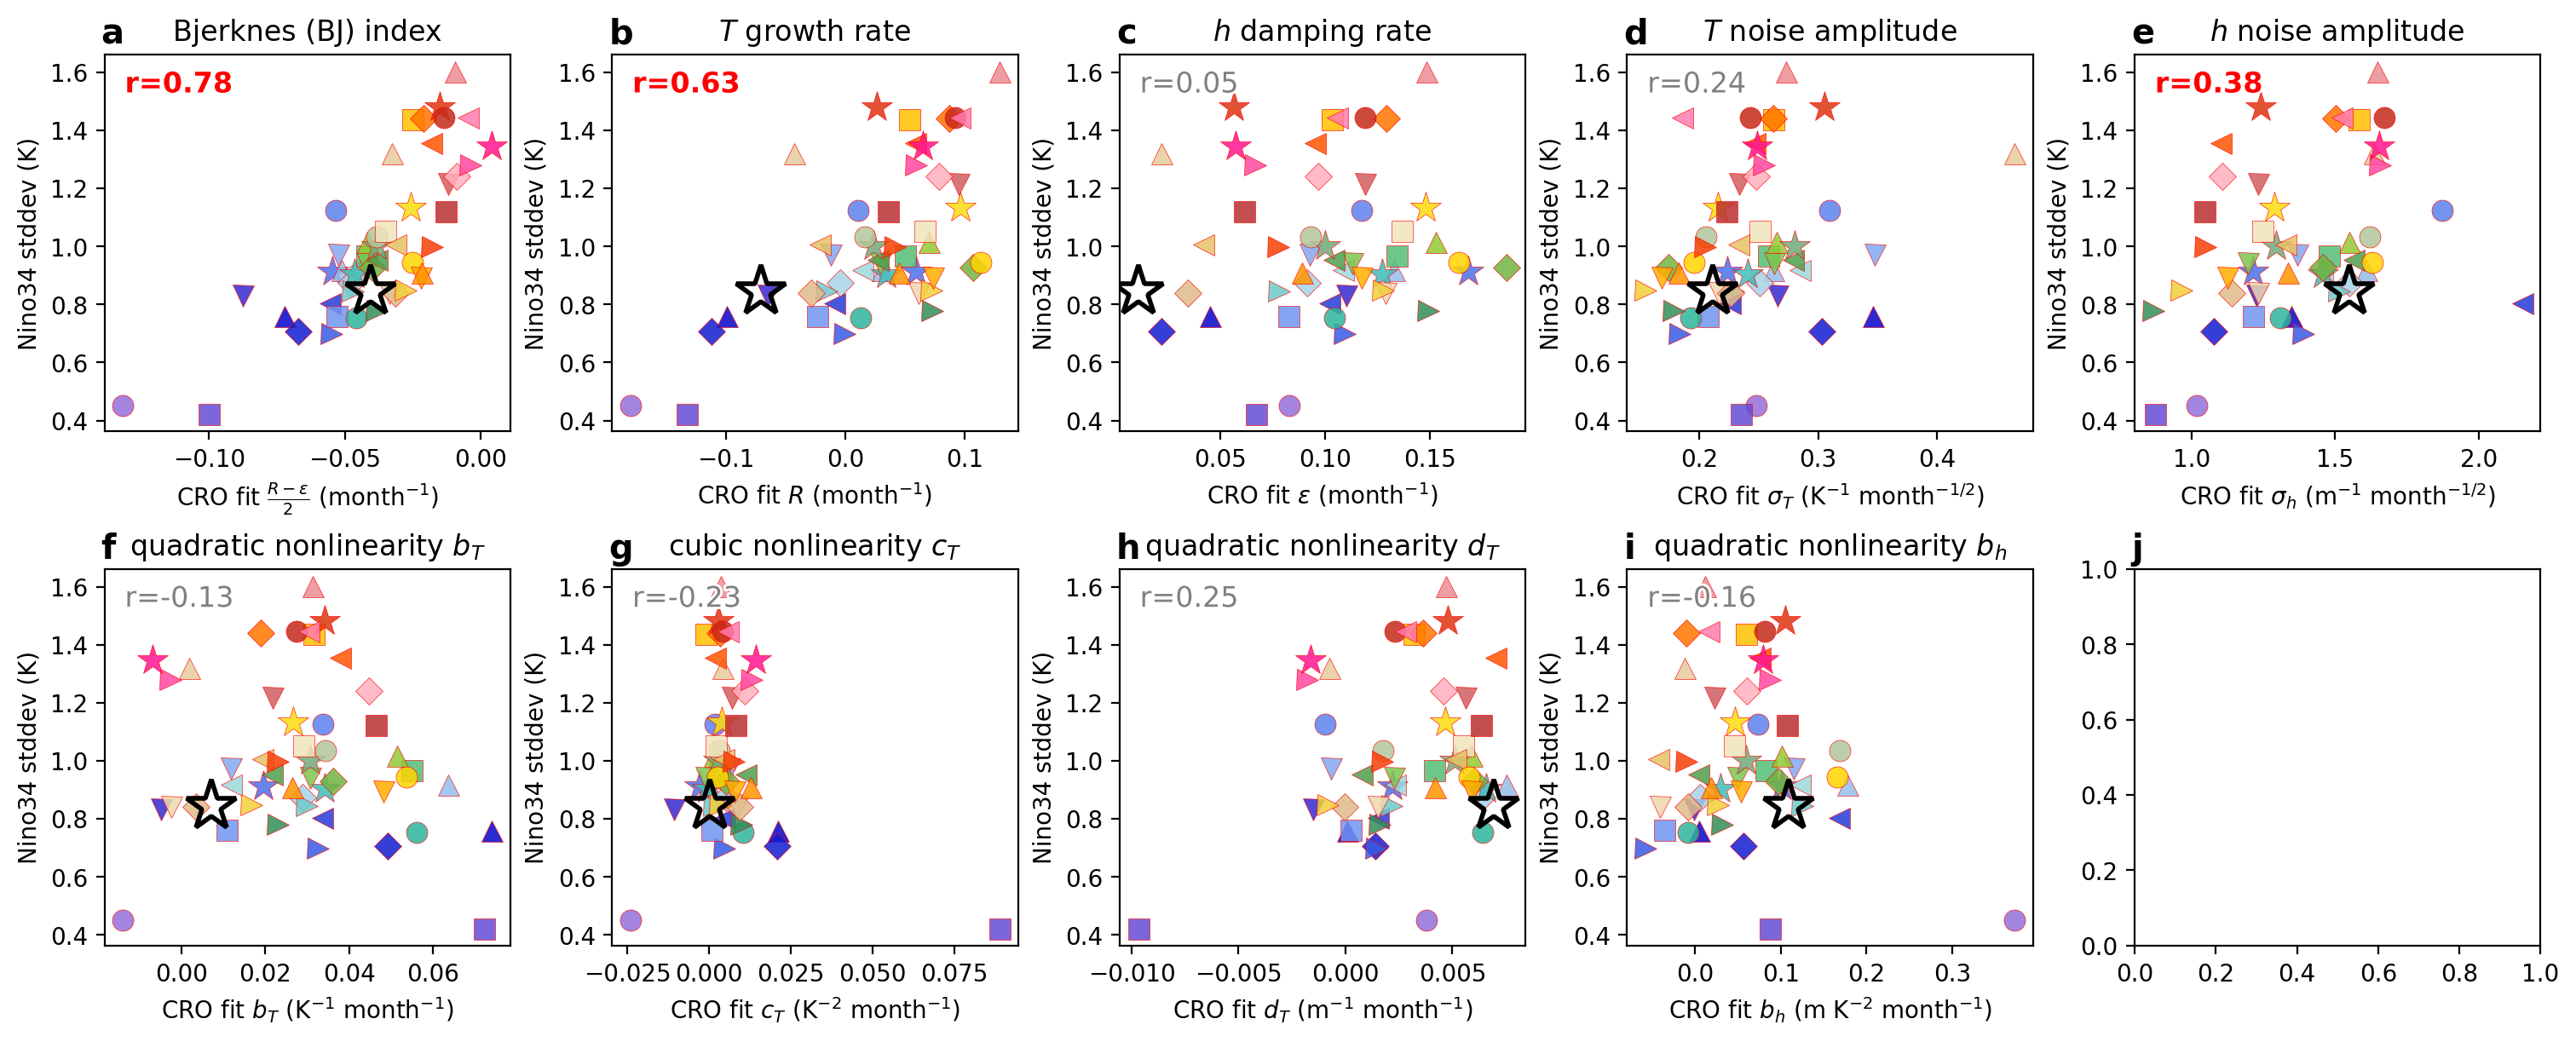

In [69]:
select_models = sorted_models

fig, axes = plt.subplots(2, 5, figsize=(15, 6), layout='compressed')

group_ds = [par_cmip, cmip_SD]
var_arrs = ['BJ', 'R', 'epsilon', 'sigma_T', 'sigma_h', 'b_T', 'c_T', 'd_T', 'b_h']

handles, labels = [], []
for i, var in enumerate(var_arrs):
    ax = axes.flat[i]

    line = ax.plot(par_obs[var], obs_SD, ls='None', marker='*', ms=22, c='black', zorder=100, mfc='none', mew=2, label='ORAS5')

    if i==0:
        handles.append(line[0])
        labels.append('ORAS5')

    metric_ds = sp.Xlinreg(group_ds[0][var], group_ds[1])
    for k, model in enumerate(select_models):
        line = ax.plot(group_ds[0][var].sel(model=model), 
                      group_ds[1].sel(model=model), 
                      **cmip_styles[model], 
                      label=model, 
                      alpha=0.85)
        if i==0:
            handles.append(line[0])
            labels.append(model)

    ax.set_title(f"{title_name[var]}")

    if metric_ds['p'].values <=0.05:
        txt = ax.text(0.05, 0.9, f"r={metric_ds['r'].values:.2f}", fontsize='large', fontweight='bold', transform=ax.transAxes, color='red')
        sp.text_border(txt)
    else:
        txt = ax.text(0.05, 0.9, f"r={metric_ds['r'].values:.2f}", fontsize='large', transform=ax.transAxes, color='gray')
        sp.text_border(txt)

    ax.set_xlabel(f'CRO fit {label_name[var]}')
    ax.set_ylabel('Nino34 stddev (K)')

# # Create a single legend at the bottom
# fig.legend(handles, labels, 
#            loc='lower center', 
#            ncol=6,  # Adjust columns based on number of models
#            bbox_to_anchor=(0.5, -0.325), frameon=True)  # Position below the figure

sp.set_legend_alphabet(fig, axes.flat, x=0.05)


/tmp/ipykernel_2565610/1044956253.py:104: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # leave space for legend


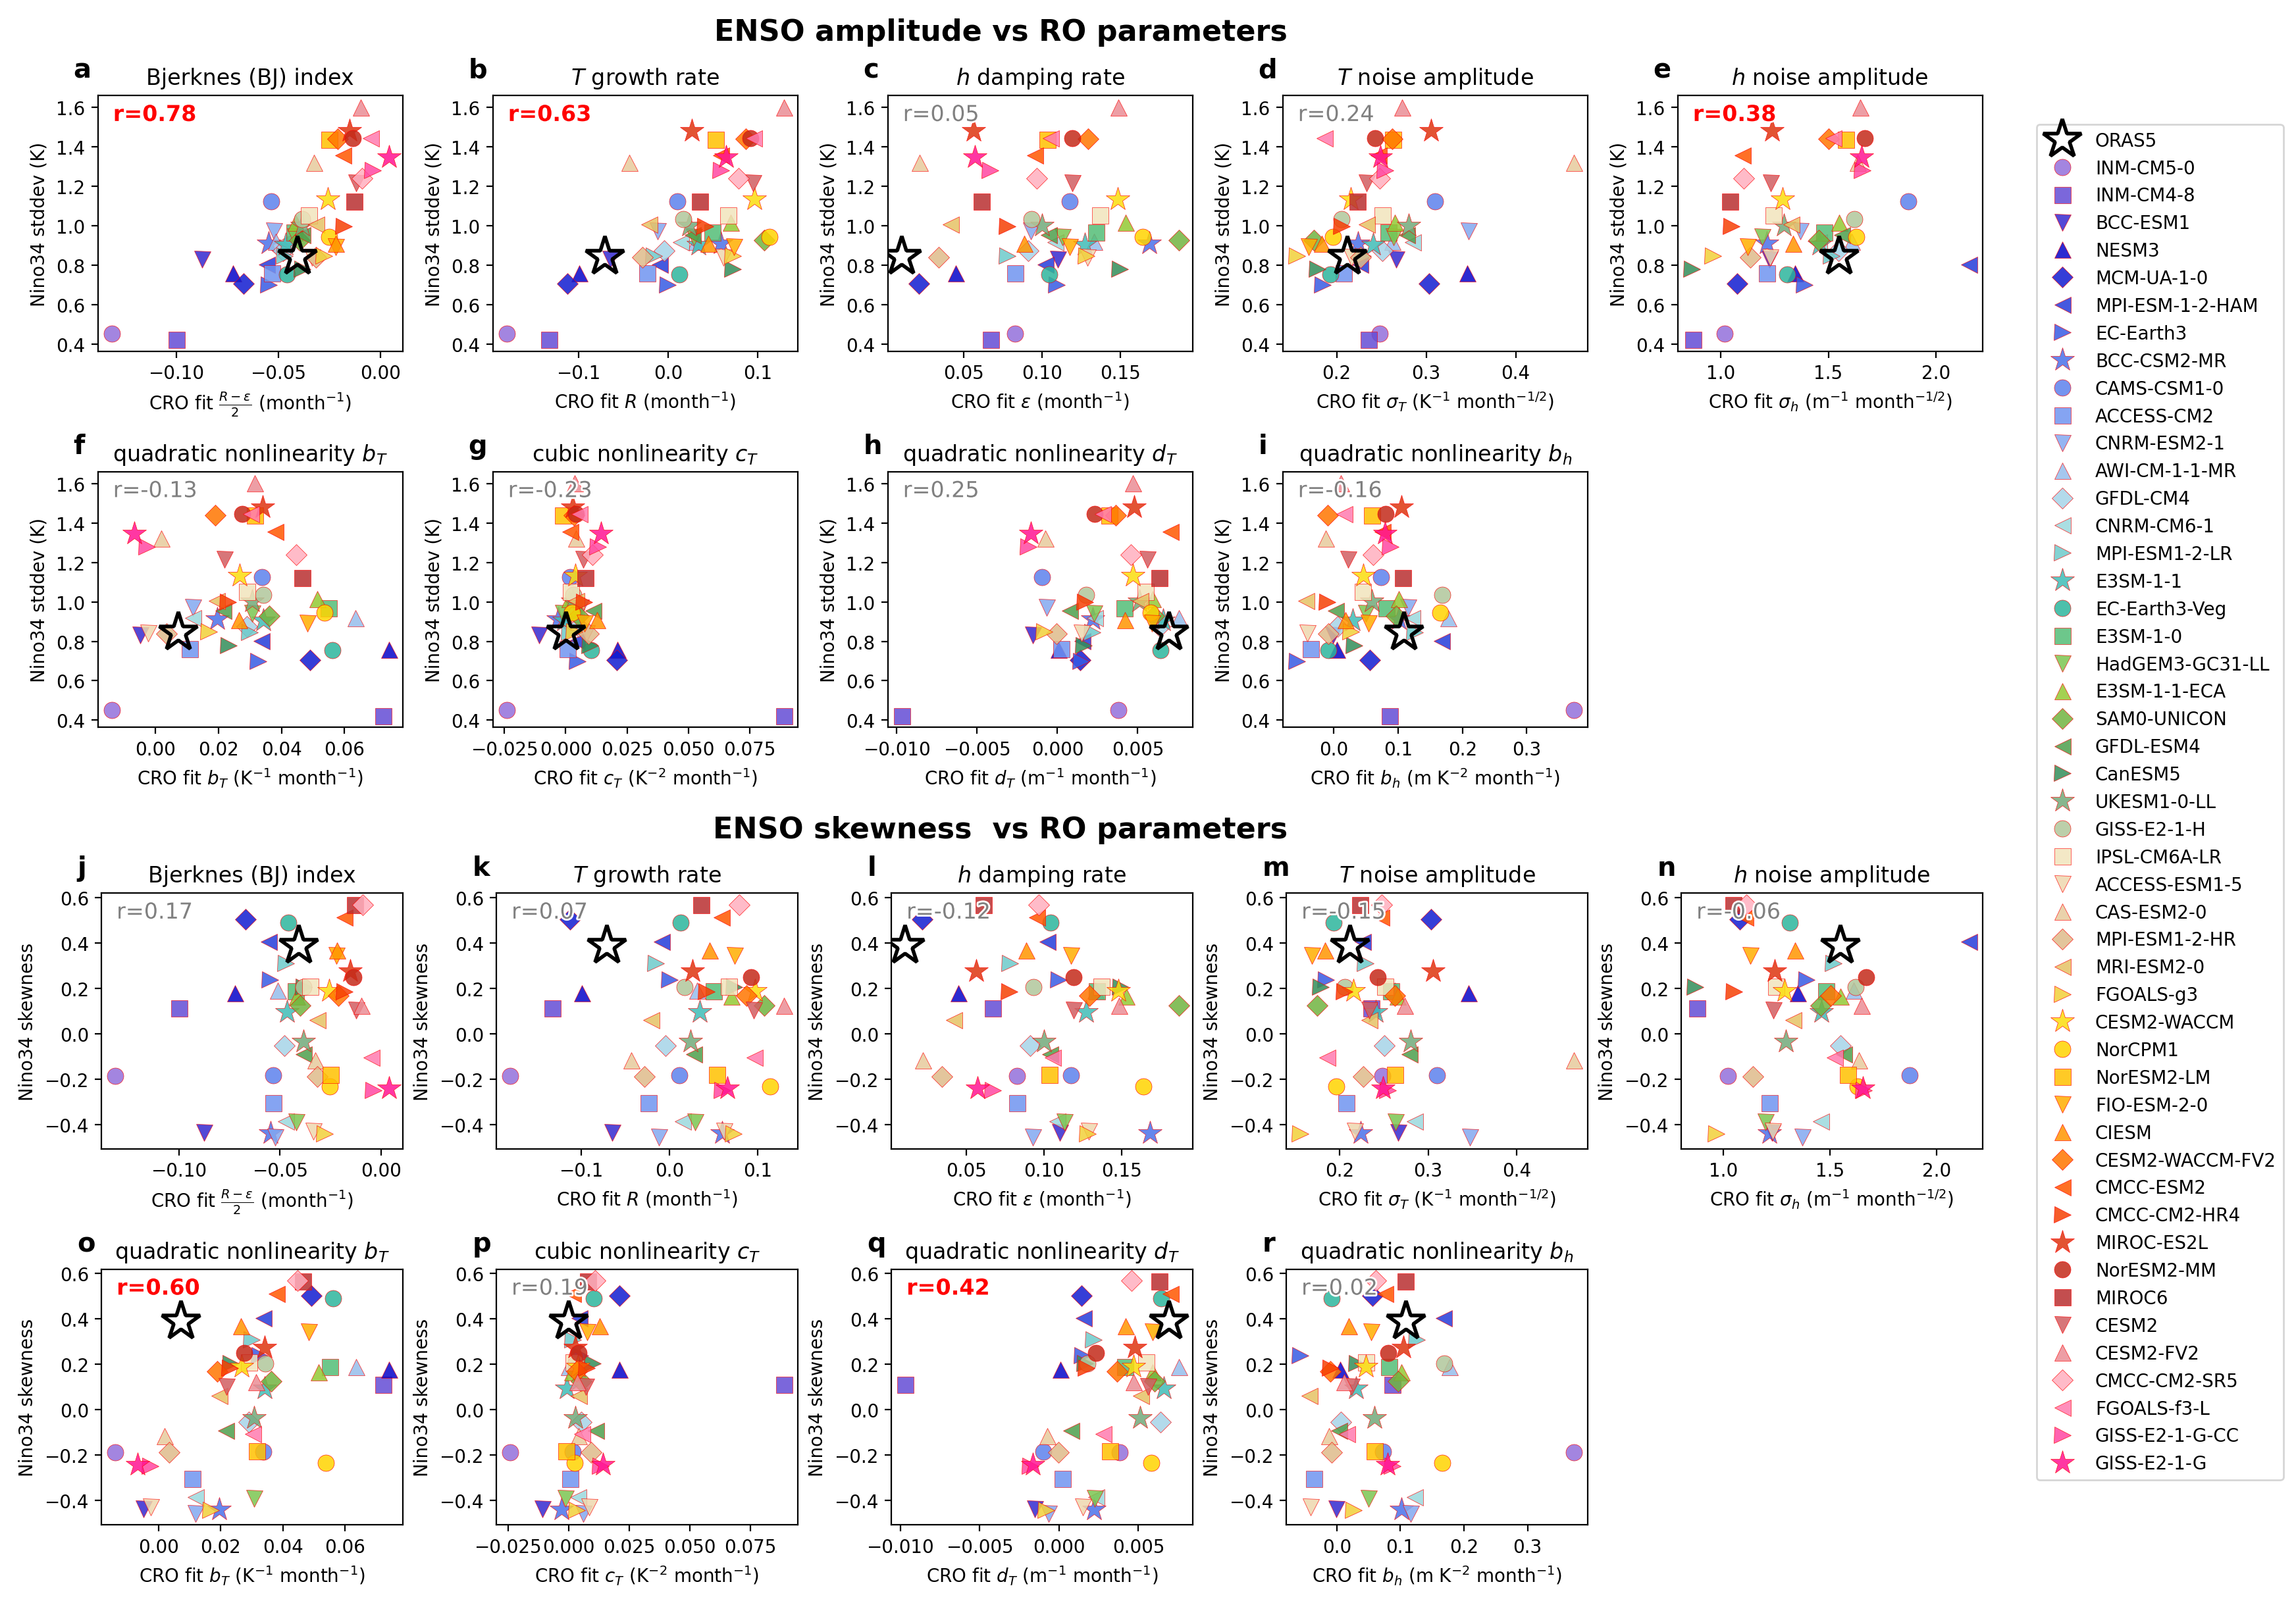

In [81]:
select_models = sorted_models
group_ds = [par_cmip, cmip_SD, cmip_SK]
var_arrs = ['BJ', 'R', 'epsilon', 'sigma_T', 'sigma_h',
            'b_T', 'c_T', 'd_T', 'b_h']

fig = plt.figure(constrained_layout=True, figsize=(15, 12))

# Create two subfigures: top for SD, bottom for SK
subfig_SD = fig.subfigures(2, 1, height_ratios=[1, 1])[0]
subfig_SK = fig.subfigures(2, 1, height_ratios=[1, 1])[1]

# ----------------------
# SD subfigure
# ----------------------
axes_SD = subfig_SD.subplots(2, 5)  # 2 rows × 5 cols
handles, labels = [], []

for i, var in enumerate(var_arrs):
    ax = axes_SD.flat[i]

    # ORAS5 observation
    line = ax.plot(par_obs[var], obs_SD, ls='None', marker='*', ms=22,
                   c='black', zorder=100, mfc='none', mew=2, label='ORAS5')
    if i == 0:
        handles.append(line[0])
        labels.append('ORAS5')

    # Linear regression & model lines
    metric_ds = sp.Xlinreg(group_ds[0][var], group_ds[1])
    for model in select_models:
        line = ax.plot(group_ds[0][var].sel(model=model),
                       group_ds[1].sel(model=model),
                       **cmip_styles[model], alpha=0.85)
        if i == 0:
            handles.append(line[0])
            labels.append(model)

    # Title per panel
    ax.set_title(f"{title_name[var]}")

    # correlation text
    color = 'red' if metric_ds['p'].values <= 0.05 else 'gray'
    weight = 'bold' if metric_ds['p'].values <= 0.05 else 'normal'
    txt = ax.text(0.05, 0.9, f"r={metric_ds['r'].values:.2f}",
                  fontsize='large', fontweight=weight,
                  transform=ax.transAxes, color=color)
    sp.text_border(txt)

    ax.set_xlabel(f'CRO fit {label_name[var]}')
    ax.set_ylabel('Nino34 stddev (K)')

axes_SD = sp.trim_axs(axes_SD, len(var_arrs))


subfig_SD.suptitle("ENSO amplitude vs RO parameters", fontsize=16, fontweight='bold')

# ----------------------
# SK subfigure
# ----------------------
axes_SK = subfig_SK.subplots(2, 5)

for i, var in enumerate(var_arrs):
    ax = axes_SK.flat[i]

    line = ax.plot(par_obs[var], obs_SK, ls='None', marker='*', ms=22,
                   c='black', zorder=100, mfc='none', mew=2)

    metric_ds = sp.Xlinreg(group_ds[0][var], group_ds[2])
    for model in select_models:
        ax.plot(group_ds[0][var].sel(model=model),
                group_ds[2].sel(model=model),
                **cmip_styles[model], alpha=0.85)

    ax.set_title(f"{title_name[var]}")

    color = 'red' if metric_ds['p'].values <= 0.05 else 'gray'
    weight = 'bold' if metric_ds['p'].values <= 0.05 else 'normal'
    txt = ax.text(0.05, 0.9, f"r={metric_ds['r'].values:.2f}",
                  fontsize='large', fontweight=weight,
                  transform=ax.transAxes, color=color)
    sp.text_border(txt)

    ax.set_xlabel(f'CRO fit {label_name[var]}')
    ax.set_ylabel('Nino34 skewness')


axes_SK = sp.trim_axs(axes_SK, len(var_arrs))

subfig_SK.suptitle("ENSO skewness  vs RO parameters", fontsize=16, fontweight='bold')

# single alphabet legend for all subfigures
sp.set_legend_alphabet(fig, list(axes_SD) + list(axes_SK), x=-0.02, y=1.1)

# Create a single legend to the right of both subfigures
fig.legend(
    handles, labels,
    loc='center left',       # center vertically
    bbox_to_anchor=(1.02, 0.5),  # slightly outside the right of the figure
    ncol=1,                  # one column (stacked vertically)
    frameon=True
)

# Optional: adjust layout so subfigures don't overlap with legend
fig.subplots_adjust(right=0.85)  # leave space for legend

plt.show()


**The ENSO amplitude is highly related the growth rate (BJ index) and a less degree to noise amplitude.**

